In [316]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
from statsmodels.formula.api import wls
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.api import qqplot
from statsmodels.formula.api import logit

In [317]:
# Import data set
df=pd.read_csv('cps_00006.csv.gz')

In [318]:
df.describe()

,YEAR,SERIAL,MONTH,HWTFINL,CPSID,ASECFLAG,HFLAG,ASECWTH,STATEFIP,METRO,...,IND,CLASSWKR,UHRSWORKT,DURUNEMP,EDUC,WKSWORK1,WKSUNEM1,FIRMSIZE,FTOTVAL,INCWAGE
count,8052104.000,8052104.000,8052104.000,4083912.000,8052104.000,4354033.000,199556.000,3968192.000,8052104.000,8052104.000,...,8052104.000,8052104.000,8052104.000,8052104.000,8052104.000,3968192.000,3968192.000,3968192.000,3968192.000,3968192.000
mean,2015.042,40640.102,4.566,3231.953,17032627474712.496,1.089,0.301,1599.300,28.013,2.508,...,2728.425,10.777,552.457,975.506,66.918,23.616,86.485,3.019,4211192.599,24045372.319
std,9.250,24960.936,2.909,1788.276,7296618147184.920,0.284,0.459,1143.516,16.118,1.014,...,3543.390,11.036,479.866,149.772,40.378,24.720,31.967,3.739,203498730.849,42714383.750
min,1996.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,-28454.000,0.000
25%,2007.000,19687.000,3.000,1632.199,20010304308800.000,1.000,0.000,819.207,13.000,2.000,...,0.000,0.000,40.000,999.000,40.000,0.000,99.000,0.000,25000.000,0.000
50%,2022.000,39132.000,3.000,3504.421,20201204064400.000,1.000,0.000,1454.890,28.000,3.000,...,0.000,13.000,999.000,999.000,73.000,8.000,99.000,1.000,50010.000,25000.000
75%,2023.000,59134.000,6.000,4479.887,20230200497400.000,1.000,1.000,2081.890,42.000,3.000,...,6890.000,22.000,999.000,999.000,92.000,52.000,99.000,7.000,88000.000,150000.000
max,2025.000,99986.000,12.000,20132.930,20250506907700.000,2.000,1.000,28654.310,56.000,4.000,...,9890.000,29.000,999.000,999.000,125.000,52.000,99.000,9.000,9999999999.000,99999999.000


In [319]:
# Check for missing values
df.isnull().sum()

YEAR               0
SERIAL             0
MONTH              0
HWTFINL      3968192
CPSID              0
ASECFLAG     3698071
HFLAG        7852548
ASECWTH      4083912
STATEFIP           0
METRO              0
HHINCOME     4083912
PERNUM             0
WTFINL       3968192
CPSIDP             0
CPSIDV             0
ASECWT       4083912
AGE                0
SEX                0
RACE               0
MARST              0
FAMSIZE            0
NCHILD             0
NCHLT5             0
CITIZEN            0
HISPAN             0
EMPSTAT            0
LABFORCE           0
OCC                0
IND                0
CLASSWKR           0
UHRSWORKT          0
DURUNEMP           0
EDUC               0
WKSWORK1     4083912
WKSUNEM1     4083912
FIRMSIZE     4083912
FTOTVAL      4083912
INCWAGE      4083912
dtype: int64

In [320]:
# Filter year from 1996 to 2016
df = df[(df['YEAR'] >= 1996) & (df['YEAR'] <= 2016)]

In [321]:
df['EDUC'] = df['EDUC'].replace(999, np.nan)
df['RACE'] = df['RACE'].replace(999, np.nan)
df['SEX'] = df['SEX'].replace(9, np.nan)
df['STATEFIP'] = df['STATEFIP'].replace(99, np.nan)
df['METRO'] = df['METRO'].replace(0, np.nan)
df['METRO'] = df['METRO'].replace(9, np.nan)
df['MARST'] = df['MARST'].replace(9, np.nan)
df['CITIZEN'] = df['CITIZEN'].replace(9, np.nan)
df['EMPSTAT'] = df['EMPSTAT'].replace(00, np.nan)
df['LABFORCE'] = df['LABFORCE'].replace(0, np.nan)
df['UHRSWORKT'] = df['UHRSWORKT'].replace(999, np.nan)
df['FTOTVAL'] = df['FTOTVAL'].replace(9999999999, np.nan)
df['INCWAGE'] = df['INCWAGE'].replace(999998, np.nan)
df['WKSUNEM1'] = df['WKSUNEM1'].replace(99, np.nan)
df['HISPAN'] = df['HISPAN'].replace(901, np.nan)
df['HISPAN'] = df['HISPAN'].replace(902, np.nan)
df['CLASSWKR'] = df['CLASSWKR'].replace(99, np.nan)
df['HHINCOME']= df['HHINCOME'].replace(9999999, np.nan)
df['WKSUNEM1'] = df['WKSUNEM1'].replace(999, np.nan)
df['DURUNEMP'] = df['DURUNEMP'].replace(999, np.nan)

In [322]:
df.isnull().sum()

YEAR               0
SERIAL             0
MONTH              0
HWTFINL      3968192
CPSID              0
ASECFLAG           0
HFLAG        3768636
ASECWTH            0
STATEFIP           0
METRO          27622
HHINCOME           0
PERNUM             0
WTFINL       3968192
CPSIDP             0
CPSIDV             0
ASECWT             0
AGE                0
SEX                0
RACE               0
MARST              0
FAMSIZE            0
NCHILD             0
NCHLT5             0
CITIZEN            0
HISPAN         11242
EMPSTAT       953436
LABFORCE      966824
OCC                0
IND                0
CLASSWKR           0
UHRSWORKT    1920566
DURUNEMP     3846790
EDUC               0
WKSWORK1           0
WKSUNEM1     3432452
FIRMSIZE           0
FTOTVAL         1644
INCWAGE            0
dtype: int64

-----
# Drop values/ clean data

In [323]:
# Drop New Jersey, Washington, Rhode Island,New York, and Hawaii
df = df[~df['STATEFIP'].isin([34, 53, 44, 36, 15])]

# Drop self employed, unpaid family workers, and those in the armed forces
df = df[~df['EMPSTAT'].isin([1])]
df = df[~df['CLASSWKR'].isin([10, 13, 14, 26,29])]

# Drop everyone not between the ages of 18 and 64
df = df[(df['AGE'] >= 18) & (df['AGE'] <= 64)]

# Drop 'Hispanic' missing values
df = df[~df['HISPAN'].isnull()]

# Drop 'FVTOTAL' missing values
df = df[~df['FTOTVAL'].isnull()]

# Drop 'METRO' missing values
df = df[~df['METRO'].isnull()]




In [324]:
df.shape

(1903520, 38)

In [325]:
df['EMPSTAT'].value_counts(normalize=True)

EMPSTAT
10.000   0.692
34.000   0.149
32.000   0.053
21.000   0.045
36.000   0.038
12.000   0.021
22.000   0.003
Name: proportion, dtype: float64

In [326]:
# Check for missing values again
df.isnull().sum()


YEAR               0
SERIAL             0
MONTH              0
HWTFINL      1903520
CPSID              0
ASECFLAG           0
HFLAG        1806290
ASECWTH            0
STATEFIP           0
METRO              0
HHINCOME           0
PERNUM             0
WTFINL       1903520
CPSIDP             0
CPSIDV             0
ASECWT             0
AGE                0
SEX                0
RACE               0
MARST              0
FAMSIZE            0
NCHILD             0
NCHLT5             0
CITIZEN            0
HISPAN             0
EMPSTAT            0
LABFORCE           0
OCC                0
IND                0
CLASSWKR           0
UHRSWORKT     497430
DURUNEMP     1812933
EDUC               0
WKSWORK1           0
WKSUNEM1     1534812
FIRMSIZE           0
FTOTVAL            0
INCWAGE            0
dtype: int64

In [327]:
# Shape of the data set after cleaning
df.shape    

(1903520, 38)

In [328]:
pd.crosstab(df['YEAR'], df['EMPSTAT'],normalize='index')

EMPSTAT,10.000,12.000,21.000,22.000,32.000,34.000,36.000
YEAR,,,,,,,
1996,0.697,0.023,0.042,0.002,0.044,0.152,0.040
1997,0.707,0.022,0.040,0.002,0.043,0.144,0.041
1998,0.714,0.023,0.037,0.001,0.045,0.139,0.041
1999,0.717,0.023,0.034,0.001,0.044,0.140,0.041
2000,0.720,0.024,0.032,0.001,0.044,0.138,0.041
2001,0.725,0.024,0.035,0.001,0.042,0.137,0.035
2002,0.709,0.022,0.045,0.002,0.045,0.142,0.035
2003,0.698,0.021,0.047,0.002,0.047,0.149,0.037
2004,0.696,0.021,0.043,0.002,0.050,0.151,0.037


In [329]:
pd.crosstab(df['EMPSTAT'],df['LABFORCE'],normalize='index')

LABFORCE,1.000,2.000
EMPSTAT,,
10.000,0.000,1.000
12.000,0.000,1.000
21.000,0.000,1.000
22.000,0.000,1.000
32.000,1.000,0.000
34.000,1.000,0.000
36.000,1.000,0.000


### Create new variables

In [330]:
# Create 'in_labor_force' as a binary variable
df['in_labor_force'] = (df['LABFORCE']==2).astype(int)

# Create 'employed' as a binary variable 1 is EMPSTAT == 10,12 and LABFORCE == 2
df['employed'] = np.nan     

mask = df['LABFORCE'] == 2   

df.loc[mask, 'employed'] = np.where(
    df.loc[mask, 'EMPSTAT'].isin([10, 12]), 1, 0)

# Create female variable
df['female'] = (df['SEX'] == 2).astype(int)

# Create treated group 
df['treated'] = ((df['AGE'] >= 18) & (df['AGE'] <= 34)).astype(int)

# create 'control' group
df['control'] = ((df['AGE'] >= 35) & (df['AGE'] <= 64)).astype(int)

# Create new variable for after year 2004
df['post'] = (df['YEAR'] >= 2004).astype(int)

# Create an interatcion term for the treatment group after 2004, DiD
df['treat_after'] = (df['treated'] & (df['post'] == 1)).astype(int)


In [331]:
# describe 'AGE' varaible
df['AGE'].describe()

count   1903520.000
mean         39.564
std          12.769
min          18.000
25%          29.000
50%          39.000
75%          50.000
max          64.000
Name: AGE, dtype: float64

In [332]:
pd.crosstab(df['employed'],df['YEAR'],normalize='index')

YEAR,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
employed,,,,,,,,,,,,,,,,,,,,,
0.000,0.029,0.028,0.026,0.024,0.023,0.041,0.052,0.055,0.050,0.046,...,0.038,0.044,0.076,0.086,0.077,0.068,0.061,0.053,0.044,0.038
1.000,0.032,0.033,0.034,0.034,0.035,0.056,0.055,0.055,0.054,0.053,...,0.053,0.053,0.051,0.051,0.050,0.050,0.050,0.050,0.050,0.047


In [333]:
df['in_labor_force'].describe()

count   1903520.000
mean          0.760
std           0.427
min           0.000
25%           1.000
50%           1.000
75%           1.000
max           1.000
Name: in_labor_force, dtype: float64

### Outcome Variables

In [334]:
# Create 'log_annual_wage' variable
df['log_annual_wage'] = np.log(df['INCWAGE'].clip(lower=1))

### Control Variables

In [335]:
# Create 'AGE_squared' variable
df['AGE_SQ'] = df['AGE'] ** 2

# Create education level variables
df['educ_HS_or_less'] = df['EDUC'].between(0, 73).astype(int)

df['educ_some_college'] = (df['EDUC'].isin([
    80, 81, 90, 91, 92,100,110])).astype(int)

df['educ_BA_or_more'] =( df['EDUC'].isin([
    111, 120, 121, 122, 123, 124, 125])).astype(int)

# Create 'is_citizen' variable
df['is_citizen'] = df['CITIZEN'].isin([1,2,3,4]).astype(int)

# Create race variables
df['white'] = (df['RACE'] == 100).astype(int)
df['black'] = (df['RACE'] == 200).astype(int)
df['other_race'] = (~df['RACE'].isin([100, 200])).astype(int)

# Create 'hispan' variable
df['hispanic'] = np.select([df['HISPAN'].between(100, 899),df['HISPAN'] == 0],[1, 0],default=np.nan).astype(int)

# Create 'married' variable
df['married'] = df['MARST'].isin([1, 2]).astype(int)

# Create 'in_metro' variable
df['in_metro'] = df['METRO'].isin([2,3,4]).astype(int)

# Create 'chlu5' variable
df['chlu5'] = (df['NCHLT5'] > 0).astype(int)

# Create 'CA' or 'PPL' variable
df['PPL'] = (df['STATEFIP'] == 6).astype(int)

In [336]:
# Create variables for interaction terms for regression
df['PPL_Treat_Post'] = df['PPL'] * df['treated'] * df['post']
df['Post_Treat'] = df['post'] * df['treated']
df['PPL_Post'] = df['post'] * df['PPL']
df['Treat_PPL']= df['treated'] * df['PPL']

## Attempt at recreating Figure One

In [337]:
#set the years between 1996 and 2016
df = df[(df['YEAR'] >= 1996) & (df['YEAR'] <= 2016)]


#Create a variable for 'CA_in_labor_force' when 'statefip' is 6 and 'in_labor_force' is 1
df['CA_in_labor_force'] = ((df['STATEFIP'] == 6) & (df['in_labor_force'] == 1)).astype(int)

# Create 'CA_in_labor_force' when statefip is not 6 and in_labor_force is 1
df['ALL_in_labor_force'] = ((df['STATEFIP'] != 6) & (df['in_labor_force'] == 1)).astype(int)

#Create a variable 'CA_younger_female' when 'statefip' is 6, female==1, age between 18 and 34
df['CA_younger_female'] = ((df['STATEFIP'] == 6) & (df['female'] == 1) & (df['AGE'] >= 18) & (df['AGE'] <= 34)).astype(int)
# Create 'CA_older_female' when statefip==6, female==1, age between 35 and 64
df['CA_older_female'] = ((df['STATEFIP'] == 6) & (df['female'] == 1) & (df['AGE'] >= 35) & (df['AGE'] <= 64)).astype(int)
#create 'ALL_younger_female' when statefip is not 6 female==1, age between 18 and 34
df['ALL_younger_female'] = ((df['STATEFIP'] != 6) & (df['female'] == 1) & (df['AGE'] >= 18) & (df['AGE'] <= 34)).astype(int)
# Create 'ALL_older_female' when statefip is not 6, female==1, age between 35 and 64
df['ALL_older_female'] = ((df['STATEFIP'] != 6) & (df['female'] == 1) & (df['AGE'] >= 35) & (df['AGE'] <= 64)).astype(int)

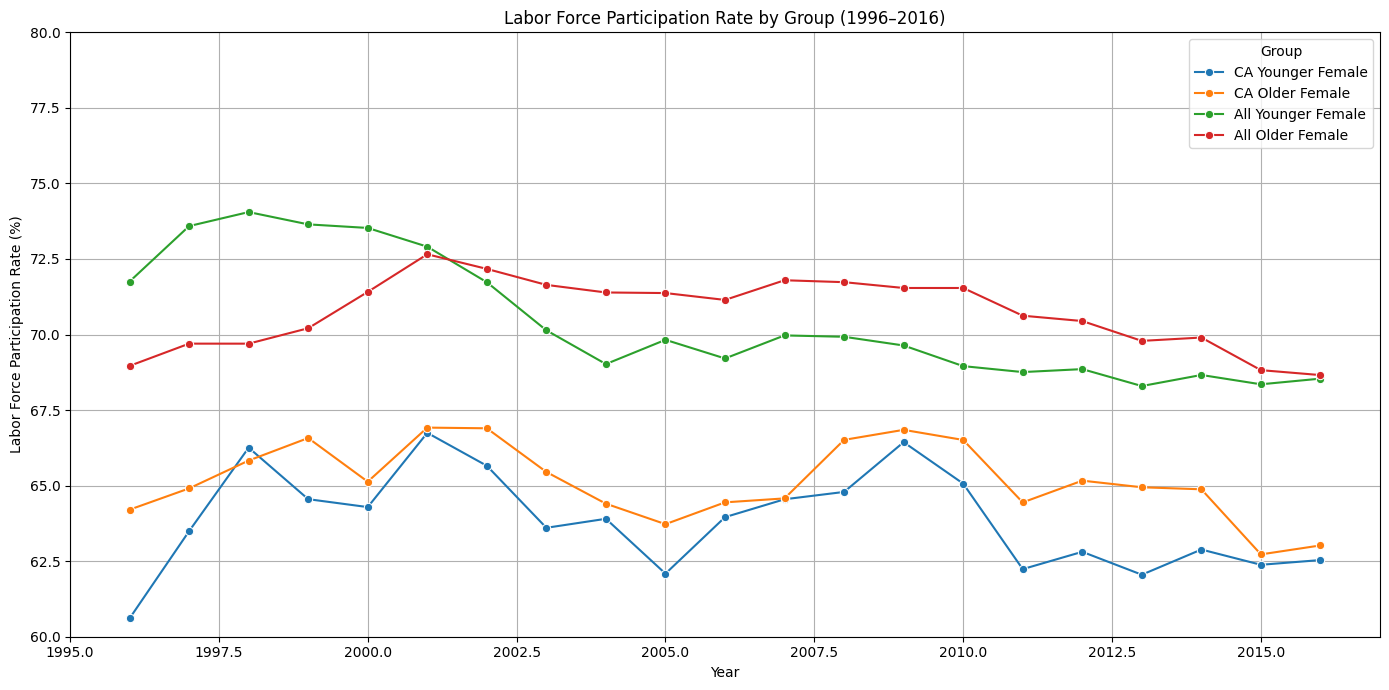

In [338]:
#CA Younger Female
ca_young = df[df['CA_younger_female'] == 1].groupby('YEAR').agg(
    participation=('CA_in_labor_force', 'mean')
).reset_index()
ca_young['Participation_Rate'] = ca_young['participation'] * 100
ca_young['Group'] = 'CA Younger Female'

#CA Older Female
ca_old = df[df['CA_older_female'] == 1].groupby('YEAR').agg(
    participation=('CA_in_labor_force', 'mean')
).reset_index()
ca_old['Participation_Rate'] = ca_old['participation'] * 100
ca_old['Group'] = 'CA Older Female'

#ALL Younger Female
all_young = df[df['ALL_younger_female'] == 1].groupby('YEAR').agg(
    participation=('ALL_in_labor_force', 'mean')
).reset_index()
all_young['Participation_Rate'] = all_young['participation'] * 100
all_young['Group'] = 'All Younger Female'

#ALL Older Female
all_old = df[df['ALL_older_female'] == 1].groupby('YEAR').agg(
    participation=('ALL_in_labor_force', 'mean')
).reset_index()
all_old['Participation_Rate'] = all_old['participation'] * 100
all_old['Group'] = 'All Older Female'

#Combine all groups
plot_df = pd.concat([
    ca_young[['YEAR', 'Participation_Rate', 'Group']],
    ca_old[['YEAR', 'Participation_Rate', 'Group']],
    all_young[['YEAR', 'Participation_Rate', 'Group']],
    all_old[['YEAR', 'Participation_Rate', 'Group']]
])

#Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, x='YEAR', y='Participation_Rate', hue='Group', marker='o')

plt.title('Labor Force Participation Rate by Group (1996–2016)')
plt.xlabel('Year')
plt.ylabel('Labor Force Participation Rate (%)')
plt.ylim(60, 80)
plt.grid(True)
plt.legend(title='Group')
plt.tight_layout()
plt.show()

------
## Table A1 Descriptive statistics for baseline labor force participation regressions 

## California Females

### Treatment

#### Pre CA PFL

In [339]:
# Create mask
PreCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 0) & (df['PPL']==1)

In [340]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.640     0.480
AGE                  26.230     4.920
educ_HS_or_less       0.500     0.500
educ_some_college     0.330     0.470
is_citizen            0.660     0.470
hispanic              0.520     0.500
white                 0.820     0.390
black                 0.060     0.230
married               0.440     0.500
chlu5                 0.350     0.480
NCHILD                0.980     1.240
HHINCOME          55298.360 52002.590
FAMSIZE               3.780     2.000
in_metro              0.990     0.080


In [341]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL: {df[PreCAPFL].shape}")

Shape of PreCAPFL: (14302, 69)


#### Post CA PFL

In [342]:
# Create Mask
PostCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==1)

In [343]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.640     0.480
AGE                  26.000     4.970
educ_HS_or_less       0.420     0.490
educ_some_college     0.370     0.480
is_citizen            0.780     0.420
hispanic              0.520     0.500
white                 0.760     0.420
black                 0.060     0.240
married               0.360     0.480
chlu5                 0.290     0.450
NCHILD                0.820     1.170
HHINCOME          76566.450 80421.500
FAMSIZE               3.800     1.930
in_metro              0.990     0.110


In [344]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL: {df[PostCAPFL].shape}")

Shape of PostCAPFL: (29012, 69)


### Comparison Group

#### Pre CA PFL

In [345]:
# Create mask
PreCAPFL= (df['control']==1) & (df['female']==1) & (df['post']== 0) & (df['PPL']==1)

In [346]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.660     0.470
AGE                  46.520     8.100
educ_HS_or_less       0.480     0.500
educ_some_college     0.280     0.450
is_citizen            0.760     0.430
hispanic              0.360     0.480
white                 0.790     0.410
black                 0.070     0.260
married               0.650     0.480
chlu5                 0.110     0.310
NCHILD                1.330     1.320
HHINCOME          67036.940 64358.710
FAMSIZE               3.390     1.760
in_metro              0.990     0.100


In [347]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (19511, 69)


#### Post CA PFL

In [348]:
# Create mask
PostCAPFL = (df['control']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==1)

In [349]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.650     0.480
AGE                  47.820     8.270
educ_HS_or_less       0.430     0.490
educ_some_college     0.270     0.440
is_citizen            0.780     0.410
hispanic              0.390     0.490
white                 0.750     0.430
black                 0.070     0.250
married               0.660     0.470
chlu5                 0.100     0.300
NCHILD                1.330     1.280
HHINCOME          90855.360 95237.170
FAMSIZE               3.450     1.720
in_metro              0.980     0.130


In [350]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (45714, 69)


## Comparison States

### Treatment

#### Pre CA PFL

In [351]:
# Create mask
PreCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 0) & (df['PPL']==0)

In [352]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.720     0.450
AGE                  26.250     5.000
educ_HS_or_less       0.460     0.500
educ_some_college     0.340     0.470
is_citizen            0.920     0.280
hispanic              0.150     0.360
white                 0.820     0.390
black                 0.130     0.340
married               0.450     0.500
chlu5                 0.350     0.480
NCHILD                0.990     1.190
HHINCOME          54174.410 49325.050
FAMSIZE               3.360     1.610
in_metro              0.750     0.430


In [353]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (113041, 69)


#### Post CA PFL

In [354]:
# Create mask
PostCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==0)

In [355]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.690     0.460
AGE                  26.170     4.990
educ_HS_or_less       0.410     0.490
educ_some_college     0.350     0.480
is_citizen            0.900     0.290
hispanic              0.170     0.380
white                 0.780     0.420
black                 0.140     0.350
married               0.390     0.490
chlu5                 0.340     0.470
NCHILD                0.950     1.190
HHINCOME          69837.470 68623.420
FAMSIZE               3.410     1.620
in_metro              0.780     0.410


In [356]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (222449, 69)


## Comparison

#### Pre CA PFL

In [357]:
# Create mask
PreCAPFL = (df['control']==1) & (df['female']==1) & (df['post']== 0) & (df['PPL']==0)

In [358]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.710     0.450
AGE                  47.070     8.150
educ_HS_or_less       0.480     0.500
educ_some_college     0.280     0.450
is_citizen            0.950     0.220
hispanic              0.090     0.290
white                 0.840     0.370
black                 0.120     0.330
married               0.680     0.470
chlu5                 0.080     0.270
NCHILD                1.120     1.210
HHINCOME          64204.430 59345.410
FAMSIZE               3.030     1.480
in_metro              0.730     0.440


In [359]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (182859, 69)


#### Post CA PFL

In [360]:
# Create mask
PostCAPFL = (df['control']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==0)

In [361]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.710     0.460
AGE                  48.170     8.270
educ_HS_or_less       0.400     0.490
educ_some_college     0.290     0.450
is_citizen            0.930     0.250
hispanic              0.120     0.320
white                 0.800     0.400
black                 0.140     0.350
married               0.660     0.470
chlu5                 0.080     0.270
NCHILD                1.130     1.210
HHINCOME          82569.420 80960.330
FAMSIZE               3.070     1.490
in_metro              0.770     0.420


In [362]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (388895, 69)


# California Males

### Treatment

#### Pre CA PFL

In [363]:
# Create mask
PreCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==1)

In [364]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.850     0.360
AGE                  26.170     4.970
educ_HS_or_less       0.560     0.500
educ_some_college     0.290     0.450
is_citizen            0.640     0.480
hispanic              0.540     0.500
white                 0.830     0.380
black                 0.050     0.220
married               0.360     0.480
chlu5                 0.230     0.420
NCHILD                0.610     1.070
HHINCOME          58478.140 50662.290
FAMSIZE               3.620     2.070
in_metro              0.990     0.080


In [365]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (13445, 69)


#### Post CA PFL

In [366]:
# Create mask
PostCAPFL = (df['treated']== 1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==1)

In [367]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.780     0.410
AGE                  25.700     5.010
educ_HS_or_less       0.500     0.500
educ_some_college     0.330     0.470
is_citizen            0.750     0.430
hispanic              0.530     0.500
white                 0.770     0.420
black                 0.050     0.220
married               0.280     0.450
chlu5                 0.180     0.390
NCHILD                0.480     0.970
HHINCOME          81771.410 82402.010
FAMSIZE               3.630     1.980
in_metro              0.990     0.110


In [368]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (27731, 69)


### Control Group

#### Pre CA PFL

In [369]:
# Create mask
PreCAPFL = (df['control']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==1)

In [370]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.850     0.360
AGE                  46.290     8.030
educ_HS_or_less       0.450     0.500
educ_some_college     0.270     0.440
is_citizen            0.760     0.430
hispanic              0.370     0.480
white                 0.810     0.400
black                 0.070     0.250
married               0.720     0.450
chlu5                 0.140     0.350
NCHILD                1.280     1.360
HHINCOME          71253.470 64185.230
FAMSIZE               3.410     1.820
in_metro              0.990     0.100


In [371]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (16753, 69)


#### Post CA PFL

In [372]:
# Create mask
PostCAPFL = (df['control']== 1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==1)

In [373]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.840     0.370
AGE                  47.790     8.250
educ_HS_or_less       0.440     0.500
educ_some_college     0.250     0.430
is_citizen            0.770     0.420
hispanic              0.400     0.490
white                 0.770     0.420
black                 0.060     0.240
married               0.720     0.450
chlu5                 0.130     0.330
NCHILD                1.250     1.290
HHINCOME          95964.810 97222.530
FAMSIZE               3.440     1.760
in_metro              0.980     0.130


In [374]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (39181, 69)


## Comparison States

### Treatment

#### Pre CA PFL

In [375]:
# Create mask
PreCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==0)

In [376]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.860     0.350
AGE                  26.000     5.060
educ_HS_or_less       0.520     0.500
educ_some_college     0.300     0.460
is_citizen            0.890     0.310
hispanic              0.170     0.370
white                 0.840     0.370
black                 0.110     0.310
married               0.380     0.480
chlu5                 0.240     0.430
NCHILD                0.610     1.020
HHINCOME          58221.180 49786.970
FAMSIZE               3.170     1.670
in_metro              0.750     0.430


In [377]:
# shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (100983, 69)


#### Post CA PFL

In [378]:
# Create Mask
PostCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==0)

In [379]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.810     0.390
AGE                  25.800     5.070
educ_HS_or_less       0.500     0.500
educ_some_college     0.310     0.460
is_citizen            0.890     0.320
hispanic              0.190     0.390
white                 0.800     0.400
black                 0.120     0.330
married               0.320     0.470
chlu5                 0.230     0.420
NCHILD                0.570     1.010
HHINCOME          74926.750 69677.910
FAMSIZE               3.230     1.680
in_metro              0.780     0.410


In [380]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (198928, 69)


## Control Group

#### Pre CA PFL

In [381]:
# Creat mask
PreCAPFL = (df['control']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==0)

In [382]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.850     0.360
AGE                  47.020     8.080
educ_HS_or_less       0.470     0.500
educ_some_college     0.250     0.430
is_citizen            0.950     0.230
hispanic              0.100     0.300
white                 0.860     0.350
black                 0.100     0.310
married               0.740     0.440
chlu5                 0.110     0.310
NCHILD                1.090     1.230
HHINCOME          67601.230 57524.060
FAMSIZE               3.060     1.510
in_metro              0.730     0.440


In [383]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (156662, 69)


#### Post CA PFL

In [384]:
# Creat mask
PostCAPFL = (df['control']==1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==0)

In [385]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['in_labor_force','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
in_labor_force        0.830     0.380
AGE                  48.260     8.240
educ_HS_or_less       0.430     0.500
educ_some_college     0.260     0.440
is_citizen            0.930     0.260
hispanic              0.120     0.330
white                 0.820     0.380
black                 0.120     0.330
married               0.710     0.450
chlu5                 0.110     0.310
NCHILD                1.090     1.230
HHINCOME          87021.540 81206.330
FAMSIZE               3.080     1.530
in_metro              0.770     0.420


In [386]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (334054, 69)


--------
# TABLE A2: Descriptive statistics for baseline employment regressions

In [387]:
# Create dataframe that drops missing values from employment
df_emp = df[~df['employed'].isnull()].copy()

# Females

## California 

### Treatment

#### Pre CA PFL

In [388]:
# Creat mask
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 1)

In [389]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.920     0.270
AGE                  26.470     4.790
educ_HS_or_less       0.430     0.490
educ_some_college     0.370     0.480
is_citizen            0.740     0.440
hispanic              0.480     0.500
white                 0.820     0.390
black                 0.060     0.240
married               0.390     0.490
chlu5                 0.280     0.450
NCHILD                0.800     1.130
HHINCOME          60730.830 51279.620
FAMSIZE               3.520     1.960
in_metro              0.990     0.080


In [390]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (9224, 69)


#### Post CA PFL

In [391]:
# Create mask
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 1)

In [392]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.900     0.300
AGE                  26.430     4.770
educ_HS_or_less       0.350     0.480
educ_some_college     0.380     0.490
is_citizen            0.830     0.380
hispanic              0.500     0.500
white                 0.760     0.430
black                 0.060     0.240
married               0.330     0.470
chlu5                 0.240     0.430
NCHILD                0.700     1.080
HHINCOME          83681.930 78886.050
FAMSIZE               3.570     1.900
in_metro              0.990     0.110


In [393]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (18428, 69)


### Control 

#### Pre CA PFL

In [394]:
# Create mask
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 1)

In [395]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.940     0.230
AGE                  45.580     7.390
educ_HS_or_less       0.410     0.490
educ_some_college     0.310     0.460
is_citizen            0.800     0.400
hispanic              0.330     0.470
white                 0.790     0.410
black                 0.070     0.260
married               0.610     0.490
chlu5                 0.090     0.280
NCHILD                1.250     1.240
HHINCOME          73247.830 63199.630
FAMSIZE               3.240     1.670
in_metro              0.990     0.100


In [396]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (12844, 69)


#### Post CA PFL

In [397]:
# Create Mask
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 1)

In [398]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                        mean       std
employed               0.930     0.250
AGE                   47.100     7.790
educ_HS_or_less        0.360     0.480
educ_some_college      0.290     0.450
is_citizen             0.820     0.380
hispanic               0.370     0.480
white                  0.740     0.440
black                  0.070     0.250
married                0.630     0.480
chlu5                  0.090     0.290
NCHILD                 1.290     1.210
HHINCOME          101001.130 95293.120
FAMSIZE                3.350     1.640
in_metro               0.980     0.130


In [399]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (29620, 69)


## Comparison States

### Treatment

#### Pre CA PFL

In [400]:
# Create mask
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 0)

In [401]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.930     0.250
AGE                  26.510     4.880
educ_HS_or_less       0.420     0.490
educ_some_college     0.350     0.480
is_citizen            0.940     0.240
hispanic              0.130     0.330
white                 0.820     0.380
black                 0.130     0.340
married               0.430     0.490
chlu5                 0.310     0.460
NCHILD                0.890     1.110
HHINCOME          56428.090 47306.860
FAMSIZE               3.170     1.550
in_metro              0.760     0.430


In [402]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (81907, 69)


#### Post CA PFL

In [403]:
# Create mask
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 0)

In [404]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.920     0.270
AGE                  26.580     4.820
educ_HS_or_less       0.350     0.480
educ_some_college     0.360     0.480
is_citizen            0.930     0.260
hispanic              0.150     0.360
white                 0.780     0.410
black                 0.140     0.350
married               0.380     0.480
chlu5                 0.310     0.460
NCHILD                0.870     1.120
HHINCOME          73240.840 66052.180
FAMSIZE               3.210     1.570
in_metro              0.790     0.410


In [405]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")


Shape of PostCAPFL (Treated): (153684, 69)


### Control

#### Pre CA PFL

In [406]:
# Create mask
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 0)

In [407]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.970     0.180
AGE                  45.930     7.420
educ_HS_or_less       0.430     0.490
educ_some_college     0.300     0.460
is_citizen            0.960     0.200
hispanic              0.080     0.280
white                 0.840     0.360
black                 0.120     0.330
married               0.660     0.470
chlu5                 0.070     0.250
NCHILD                1.140     1.170
HHINCOME          68532.610 56335.730
FAMSIZE               3.020     1.410
in_metro              0.730     0.440


In [408]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (130009, 69)


#### Post CA PFL

In [409]:
# Create mask
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 0)

In [410]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.950     0.210
AGE                  47.300     7.800
educ_HS_or_less       0.350     0.480
educ_some_college     0.310     0.460
is_citizen            0.940     0.230
hispanic              0.110     0.310
white                 0.810     0.400
black                 0.140     0.340
married               0.650     0.480
chlu5                 0.080     0.260
NCHILD                1.150     1.160
HHINCOME          90107.960 79612.720
FAMSIZE               3.050     1.420
in_metro              0.770     0.420


In [411]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (274960, 69)


# Males

## California

### Treatment

#### Pre CA PFL

In [412]:
# Create mask
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 1)

In [413]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.910     0.280
AGE                  26.750     4.750
educ_HS_or_less       0.560     0.500
educ_some_college     0.280     0.450
is_citizen            0.620     0.480
hispanic              0.560     0.500
white                 0.850     0.350
black                 0.040     0.210
married               0.400     0.490
chlu5                 0.260     0.440
NCHILD                0.680     1.090
HHINCOME          58920.130 48357.820
FAMSIZE               3.600     2.070
in_metro              0.990     0.080


In [414]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (11408, 69)


#### Post CA PFL

In [415]:
# Create mask
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 1)

In [416]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.880     0.320
AGE                  26.570     4.750
educ_HS_or_less       0.500     0.500
educ_some_college     0.310     0.460
is_citizen            0.730     0.450
hispanic              0.550     0.500
white                 0.790     0.400
black                 0.050     0.210
married               0.330     0.470
chlu5                 0.220     0.410
NCHILD                0.570     1.030
HHINCOME          83065.580 78549.110
FAMSIZE               3.580     1.980
in_metro              0.990     0.110


In [417]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (21672, 69)


### Control Group

#### Pre CA PFL

In [418]:
# Create mask
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 1)

In [419]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.940     0.230
AGE                  45.390     7.510
educ_HS_or_less       0.430     0.490
educ_some_college     0.270     0.440
is_citizen            0.750     0.440
hispanic              0.380     0.480
white                 0.810     0.390
black                 0.060     0.240
married               0.750     0.440
chlu5                 0.160     0.370
NCHILD                1.360     1.360
HHINCOME          76372.940 65544.100
FAMSIZE               3.490     1.800
in_metro              0.990     0.080


In [420]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (14272, 69)


#### Post CA PFL

In [421]:
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 1)

In [422]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                        mean        std
employed               0.930      0.260
AGE                   46.840      7.820
educ_HS_or_less        0.420      0.490
educ_some_college      0.250      0.430
is_citizen             0.760      0.430
hispanic               0.420      0.490
white                  0.780      0.420
black                  0.050      0.220
married                0.750      0.440
chlu5                  0.140      0.350
NCHILD                 1.350      1.300
HHINCOME          103439.860 100278.840
FAMSIZE                3.530      1.740
in_metro               0.980      0.120


In [423]:
# shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (32813, 69)


## Comparison States

### Treatment

#### Pre CA PFL

In [424]:
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 0)

In [425]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.920     0.260
AGE                  26.570     4.880
educ_HS_or_less       0.520     0.500
educ_some_college     0.290     0.450
is_citizen            0.890     0.310
hispanic              0.170     0.380
white                 0.860     0.350
black                 0.100     0.290
married               0.420     0.490
chlu5                 0.270     0.440
NCHILD                0.670     1.050
HHINCOME          58323.170 47427.380
FAMSIZE               3.110     1.640
in_metro              0.750     0.430


In [426]:
# shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (86443, 69)


#### Post CA PFL

In [427]:
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 0)

In [428]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.900     0.300
AGE                  26.590     4.830
educ_HS_or_less       0.480     0.500
educ_some_college     0.300     0.460
is_citizen            0.880     0.330
hispanic              0.200     0.400
white                 0.810     0.390
black                 0.110     0.310
married               0.380     0.480
chlu5                 0.270     0.440
NCHILD                0.670     1.060
HHINCOME          75240.020 65094.950
FAMSIZE               3.150     1.650
in_metro              0.790     0.410


In [429]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (160663, 69)


### Control Group

#### Pre CA PFL

In [430]:
# Create mask
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 0)

In [431]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.960     0.200
AGE                  45.960     7.490
educ_HS_or_less       0.440     0.500
educ_some_college     0.260     0.440
is_citizen            0.940     0.230
hispanic              0.100     0.300
white                 0.870     0.330
black                 0.090     0.290
married               0.760     0.420
chlu5                 0.120     0.320
NCHILD                1.190     1.250
HHINCOME          73068.770 58391.420
FAMSIZE               3.160     1.510
in_metro              0.740     0.440


In [432]:
# shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (132415, 69)


#### Post CA PFL

In [433]:
# Create Mask
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 0)

In [434]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['employed','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
employed              0.940     0.230
AGE                  47.230     7.820
educ_HS_or_less       0.400     0.490
educ_some_college     0.260     0.440
is_citizen            0.920     0.270
hispanic              0.130     0.330
white                 0.840     0.370
black                 0.110     0.310
married               0.750     0.430
chlu5                 0.120     0.330
NCHILD                1.200     1.240
HHINCOME          95607.310 83421.100
FAMSIZE               3.190     1.520
in_metro              0.780     0.420


In [435]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (276680, 69)


-------
# TABLE A3: Descriptive statistics for baseline unemployment duration regressions

In [436]:
# Drop Missing values 
df_emp = df_emp[~df_emp['WKSUNEM1'].isnull()]

# California

## Females

### Treatment

#### Pre CA PFL

In [437]:
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [438]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','YEAR','female','employed']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std','median','max','min']).T.round(2)

print(summary)

                       mean       std    median        max       min
WKSUNEM1             16.810    12.900    13.000     51.000     1.000
AGE                  25.600     5.060    25.000     34.000    18.000
educ_HS_or_less       0.500     0.500     1.000      1.000     0.000
educ_some_college     0.340     0.480     0.000      1.000     0.000
is_citizen            0.720     0.450     1.000      1.000     0.000
hispanic              0.500     0.500     0.000      1.000     0.000
white                 0.820     0.380     1.000      1.000     0.000
black                 0.070     0.260     0.000      1.000     0.000
married               0.370     0.480     0.000      1.000     0.000
chlu5                 0.290     0.450     0.000      1.000     0.000
NCHILD                0.890     1.250     0.000      9.000     0.000
HHINCOME          51416.110 50635.840 39080.000 546567.000 -4087.000
FAMSIZE               3.570     1.840     3.000     13.000     1.000
in_metro              0.990     0.

In [439]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (931, 69)


#### Post CA PFL

In [440]:
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [441]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             19.960    13.600
AGE                  25.610     4.820
educ_HS_or_less       0.430     0.490
educ_some_college     0.370     0.480
is_citizen            0.800     0.400
hispanic              0.540     0.500
white                 0.760     0.420
black                 0.090     0.280
married               0.270     0.450
chlu5                 0.230     0.420
NCHILD                0.690     1.110
HHINCOME          67947.880 64329.800
FAMSIZE               3.590     1.860
in_metro              0.980     0.130


In [442]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (2068, 69)


### Control Group

#### Pre CA PFL

In [443]:
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [444]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             18.790    12.780
AGE                  44.870     7.050
educ_HS_or_less       0.510     0.500
educ_some_college     0.270     0.450
is_citizen            0.710     0.460
hispanic              0.420     0.490
white                 0.770     0.420
black                 0.100     0.300
married               0.540     0.500
chlu5                 0.090     0.290
NCHILD                1.420     1.420
HHINCOME          50854.390 49113.470
FAMSIZE               3.380     1.930
in_metro              0.990     0.110


In [445]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (976, 69)


#### Post CA PFL

In [446]:
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [447]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             21.130    13.490
AGE                  46.430     7.590
educ_HS_or_less       0.450     0.500
educ_some_college     0.280     0.450
is_citizen            0.730     0.440
hispanic              0.440     0.500
white                 0.770     0.420
black                 0.070     0.250
married               0.550     0.500
chlu5                 0.080     0.280
NCHILD                1.370     1.310
HHINCOME          71709.770 74460.470
FAMSIZE               3.390     1.780
in_metro              0.980     0.140


In [448]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (2244, 69)


## Comparison States

## Treatment

#### Pre CA PFL

In [449]:
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [450]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             15.200    12.190
AGE                  25.270     4.900
educ_HS_or_less       0.540     0.500
educ_some_college     0.310     0.460
is_citizen            0.940     0.240
hispanic              0.130     0.340
white                 0.770     0.420
black                 0.170     0.380
married               0.320     0.470
chlu5                 0.290     0.450
NCHILD                0.880     1.150
HHINCOME          43831.460 40750.410
FAMSIZE               3.190     1.600
in_metro              0.740     0.440


In [451]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (8452, 69)


#### Post CA PFL

In [452]:
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [453]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             18.360    13.450
AGE                  25.490     4.770
educ_HS_or_less       0.460     0.500
educ_some_college     0.360     0.480
is_citizen            0.930     0.260
hispanic              0.160     0.370
white                 0.730     0.450
black                 0.190     0.390
married               0.260     0.440
chlu5                 0.300     0.460
NCHILD                0.870     1.150
HHINCOME          56611.720 56105.180
FAMSIZE               3.260     1.630
in_metro              0.780     0.410


In [454]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (16159, 69)


### Control Group

#### Pre CA PFL

In [455]:
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 0) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [456]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             16.610    12.130
AGE                  44.940     7.120
educ_HS_or_less       0.510     0.500
educ_some_college     0.300     0.460
is_citizen            0.940     0.240
hispanic              0.100     0.300
white                 0.810     0.390
black                 0.140     0.350
married               0.560     0.500
chlu5                 0.060     0.240
NCHILD                1.150     1.200
HHINCOME          48544.540 42982.520
FAMSIZE               2.960     1.460
in_metro              0.710     0.460


In [457]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (7553, 69)


#### Post CA PFL

In [458]:
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==1) & (df_emp['post']== 1) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [459]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             19.320    13.230
AGE                  46.470     7.650
educ_HS_or_less       0.410     0.490
educ_some_college     0.330     0.470
is_citizen            0.930     0.260
hispanic              0.130     0.340
white                 0.780     0.420
black                 0.160     0.360
married               0.530     0.500
chlu5                 0.070     0.260
NCHILD                1.170     1.200
HHINCOME          62193.010 59951.460
FAMSIZE               3.020     1.510
in_metro              0.760     0.430


In [460]:
# shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (17019, 69)


# Males

## California

### Treated

#### Pre CA PFL

In [461]:
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [462]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             17.480    12.260
AGE                  25.880     4.860
educ_HS_or_less       0.640     0.480
educ_some_college     0.250     0.430
is_citizen            0.630     0.480
hispanic              0.580     0.490
white                 0.870     0.340
black                 0.040     0.200
married               0.350     0.480
chlu5                 0.250     0.430
NCHILD                0.650     1.090
HHINCOME          50049.310 47058.040
FAMSIZE               3.650     2.030
in_metro              0.990     0.110


In [463]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (1367, 69)


#### Post CA PFL

In [464]:
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [465]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             20.130    13.170
AGE                  25.680     4.770
educ_HS_or_less       0.610     0.490
educ_some_college     0.280     0.450
is_citizen            0.710     0.450
hispanic              0.580     0.490
white                 0.800     0.400
black                 0.060     0.240
married               0.260     0.440
chlu5                 0.200     0.400
NCHILD                0.510     1.000
HHINCOME          69350.320 67615.500
FAMSIZE               3.730     2.020
in_metro              0.980     0.140


In [466]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (3064, 69)


### Control Group

#### Pre CA PFL

In [467]:
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [468]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             18.620    12.370
AGE                  44.500     7.430
educ_HS_or_less       0.550     0.500
educ_some_college     0.250     0.430
is_citizen            0.650     0.480
hispanic              0.450     0.500
white                 0.810     0.390
black                 0.070     0.260
married               0.680     0.470
chlu5                 0.170     0.370
NCHILD                1.380     1.480
HHINCOME          52227.080 52604.550
FAMSIZE               3.530     1.930
in_metro              0.980     0.120


In [469]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (1172, 69)


#### Post CA PFL

In [470]:
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 1) & (df_emp['WKSUNEM1'] > 0)

In [471]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             20.500    13.110
AGE                  46.200     7.660
educ_HS_or_less       0.560     0.500
educ_some_college     0.230     0.420
is_citizen            0.660     0.470
hispanic              0.510     0.500
white                 0.800     0.400
black                 0.050     0.220
married               0.690     0.460
chlu5                 0.140     0.350
NCHILD                1.340     1.370
HHINCOME          69531.850 72120.390
FAMSIZE               3.580     1.910
in_metro              0.980     0.140


In [472]:
# shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (2847, 69)


### Comparison States

#### Pre CA PFL

In [473]:
PreCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [474]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             16.110    12.010
AGE                  25.110     4.860
educ_HS_or_less       0.660     0.470
educ_some_college     0.240     0.430
is_citizen            0.910     0.290
hispanic              0.170     0.380
white                 0.820     0.380
black                 0.120     0.330
married               0.300     0.460
chlu5                 0.220     0.410
NCHILD                0.570     1.030
HHINCOME          47667.440 40998.620
FAMSIZE               3.190     1.680
in_metro              0.720     0.450


In [475]:
# shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (10510, 69)


#### Post CA PFL

In [476]:
PostCAPFL = (df_emp['treated']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [477]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             18.730    12.980
AGE                  25.390     4.800
educ_HS_or_less       0.610     0.490
educ_some_college     0.280     0.450
is_citizen            0.890     0.310
hispanic              0.200     0.400
white                 0.780     0.410
black                 0.140     0.340
married               0.250     0.440
chlu5                 0.220     0.410
NCHILD                0.560     1.020
HHINCOME          62065.740 56393.190
FAMSIZE               3.240     1.710
in_metro              0.770     0.420


In [478]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (20911, 69)


#### Control Group

#### Pre CA PFL

In [479]:
PreCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 0) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [480]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             17.000    11.570
AGE                  45.270     7.260
educ_HS_or_less       0.570     0.490
educ_some_college     0.260     0.440
is_citizen            0.930     0.260
hispanic              0.120     0.330
white                 0.840     0.370
black                 0.110     0.310
married               0.650     0.480
chlu5                 0.110     0.310
NCHILD                1.060     1.260
HHINCOME          49072.630 40436.330
FAMSIZE               3.000     1.580
in_metro              0.700     0.460


In [481]:
# Shape of PreCAPFL
print(f"Shape of PreCAPFL (Control): {df_emp[PreCAPFL].shape}")

Shape of PreCAPFL (Control): (9120, 69)


#### Post CA PFL

In [482]:
PostCAPFL = (df_emp['control']==1) & (df_emp['female']==0) & (df_emp['post']== 1) & (df_emp['PPL']== 0) & (df_emp['WKSUNEM1'] > 0)

In [483]:
pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['WKSUNEM1','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']
summary = df_emp.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
WKSUNEM1             19.160    12.710
AGE                  46.670     7.730
educ_HS_or_less       0.540     0.500
educ_some_college     0.270     0.440
is_citizen            0.900     0.300
hispanic              0.160     0.370
white                 0.810     0.390
black                 0.130     0.330
married               0.620     0.480
chlu5                 0.110     0.310
NCHILD                1.060     1.250
HHINCOME          62110.210 57853.170
FAMSIZE               3.030     1.600
in_metro              0.760     0.430


In [484]:
# Shape of PostCAPFL
print(f"Shape of PostCAPFL (Control): {df_emp[PostCAPFL].shape}")

Shape of PostCAPFL (Control): (20461, 69)


- - - - - - -

-------
# TABLE A4 Descriptive statistics for baseline earnings regressions

Female California Treatment Pre-CA-PFL

In [485]:
PreCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 0) & (df['PPL']==1) & (df['employed']==1)

# create 'UHRSWORKT' when statefip==6, age between 18 and 34, between 1996 and 2004, female==1, employed==1
subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.030     2.390
AGE                  26.590     4.740
educ_HS_or_less       0.410     0.490
educ_some_college     0.380     0.480
is_citizen            0.740     0.440
hispanic              0.470     0.500
white                 0.810     0.390
black                 0.060     0.230
married               0.390     0.490
chlu5                 0.270     0.450
NCHILD                0.780     1.110
HHINCOME          62445.590 51689.270
FAMSIZE               3.460     1.950
in_metro              0.990     0.080
WKSWORK1             43.590    15.580
avg_UHRSWORKT        70.120    32.870


In [486]:
#shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (8470, 70)


Female California Treatment Post-CA-PFL

In [487]:
PostCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(2004, 2016)) &  # Years 2004–2016
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.250     2.490
AGE                  26.530     4.730
educ_HS_or_less       0.330     0.470
educ_some_college     0.380     0.490
is_citizen            0.830     0.370
hispanic              0.490     0.500
white                 0.760     0.430
black                 0.050     0.230
married               0.340     0.470
chlu5                 0.240     0.420
NCHILD                0.690     1.060
HHINCOME          86667.110 80805.770
FAMSIZE               3.520     1.880
in_metro              0.990     0.110
WKSWORK1             43.700    15.660
avg_UHRSWORKT       102.940     8.040


In [488]:
#shape of PreCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (16552, 70)


Female California Comparison Pre-CA-PFL

In [489]:
PreCAPFL = (df['treated']==0) & (df['female']==1) & (df['post']== 0) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.780     1.720
AGE                  45.620     7.380
educ_HS_or_less       0.400     0.490
educ_some_college     0.320     0.460
is_citizen            0.810     0.390
hispanic              0.320     0.470
white                 0.790     0.410
black                 0.070     0.260
married               0.620     0.490
chlu5                 0.090     0.280
NCHILD                1.240     1.220
HHINCOME          74848.690 63420.740
FAMSIZE               3.220     1.650
in_metro              0.990     0.100
WKSWORK1             47.740    11.060
avg_UHRSWORKT        70.120    30.710


In [490]:
#shape of PreCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (12118, 70)


Female California Comparison Post-CA-PFL

In [491]:
PostCAPFL = (df['treated']==0) & (df['female']==1) & (df['post']== 1) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(2004, 2016)) &  # Years 2004–2016
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                        mean       std
log_annual_wage       10.100     1.790
AGE                   47.120     7.790
educ_HS_or_less        0.350     0.480
educ_some_college      0.290     0.450
is_citizen             0.830     0.380
hispanic               0.360     0.480
white                  0.740     0.440
black                  0.070     0.250
married                0.630     0.480
chlu5                  0.090     0.290
NCHILD                 1.280     1.200
HHINCOME          103733.340 96368.620
FAMSIZE                3.330     1.630
in_metro               0.980     0.130
WKSWORK1              48.090    10.820
avg_UHRSWORKT        100.290    10.750


In [492]:
#shape of PostCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PreCAPFL (Treated): (27577, 70)


Female Comparison Treatment Post-CA-PFL

In [493]:
PostCAPFL = (df['treated']==1) & (df['female']==1) & (df['post']== 1) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(2004, 2016)) &  # Years 1996–2003
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.340     2.240
AGE                  26.710     4.790
educ_HS_or_less       0.330     0.470
educ_some_college     0.370     0.480
is_citizen            0.930     0.260
hispanic              0.150     0.360
white                 0.790     0.400
black                 0.130     0.340
married               0.390     0.490
chlu5                 0.310     0.460
NCHILD                0.870     1.110
HHINCOME          75354.490 66708.730
FAMSIZE               3.180     1.550
in_metro              0.790     0.410
WKSWORK1             44.500    14.680
avg_UHRSWORKT        99.740     5.750


In [494]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (141317, 70)


Female Comparison Comparison Pre-CA-PFL

In [495]:
PreCAPFL = (df['treated']==0) & (df['female']==1) & (df['post']== 0) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.760     1.530
AGE                  45.970     7.420
educ_HS_or_less       0.420     0.490
educ_some_college     0.300     0.460
is_citizen            0.960     0.200
hispanic              0.080     0.280
white                 0.850     0.360
black                 0.120     0.320
married               0.670     0.470
chlu5                 0.070     0.250
NCHILD                1.140     1.160
HHINCOME          69320.000 56444.720
FAMSIZE               3.020     1.410
in_metro              0.730     0.440
WKSWORK1             48.100    10.320
avg_UHRSWORKT        78.000    33.940


In [496]:
#shape of PostCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (125490, 70)


Female Comparison Comparison Post-CA-PFL

In [497]:
PostCAPFL = (df['treated']==0) & (df['female']==1) & (df['post']== 1) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 18–34
    (df['YEAR'].between(2004, 2016)) &  # Years 1996–2003
    (df['female'] == 1) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage      10.080     1.580
AGE                  47.320     7.800
educ_HS_or_less       0.340     0.470
educ_some_college     0.300     0.460
is_citizen            0.950     0.230
hispanic              0.100     0.310
white                 0.810     0.390
black                 0.130     0.340
married               0.660     0.470
chlu5                 0.080     0.260
NCHILD                1.160     1.150
HHINCOME          91737.940 80043.810
FAMSIZE               3.060     1.410
in_metro              0.770     0.420
WKSWORK1             48.550     9.990
avg_UHRSWORKT        96.700     6.620


In [498]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (262314, 70)


MALE

Male California Treatment Pre-CA-PFL

In [499]:
PreCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==1) & (df['employed']==1)

# create 'UHRSWORKT' when statefip==6, age between 18 and 34, between 1996 and 2004, female==1, employed==1
subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Male
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.470     2.010
AGE                  26.930     4.690
educ_HS_or_less       0.550     0.500
educ_some_college     0.280     0.450
is_citizen            0.620     0.480
hispanic              0.560     0.500
white                 0.850     0.350
black                 0.040     0.200
married               0.410     0.490
chlu5                 0.260     0.440
NCHILD                0.690     1.090
HHINCOME          59990.050 48288.290
FAMSIZE               3.570     2.060
in_metro              0.990     0.080
WKSWORK1             46.200    13.090
avg_UHRSWORKT        72.630    33.500


In [500]:
#shape of PostCAPFL
print(f"Shape of PreCAPFL (Treated): {df[PreCAPFL].shape}")

Shape of PreCAPFL (Treated): (10431, 70)


Male California Treatment Post-CA-PFL

In [501]:
PostCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(2004, 2016)) &  # Years 2004–2016
    (df['female'] == 0) &                  # Male
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.610     2.280
AGE                  26.800     4.680
educ_HS_or_less       0.480     0.500
educ_some_college     0.310     0.460
is_citizen            0.720     0.450
hispanic              0.550     0.500
white                 0.800     0.400
black                 0.040     0.200
married               0.350     0.480
chlu5                 0.230     0.420
NCHILD                0.590     1.040
HHINCOME          85521.310 80457.390
FAMSIZE               3.540     1.980
in_metro              0.990     0.110
WKSWORK1             45.370    14.160
avg_UHRSWORKT       105.270     7.180


In [502]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (19095, 70)


Male California Comparison Pre-CA-PFL

In [503]:
PreCAPFL = (df['treated']==0) & (df['female']==0) & (df['post']== 0) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Mmale
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage      10.340     1.410
AGE                  45.370     7.480
educ_HS_or_less       0.420     0.490
educ_some_college     0.270     0.450
is_citizen            0.750     0.430
hispanic              0.370     0.480
white                 0.820     0.390
black                 0.060     0.230
married               0.750     0.430
chlu5                 0.160     0.370
NCHILD                1.370     1.350
HHINCOME          78149.920 65971.710
FAMSIZE               3.480     1.790
in_metro              0.990     0.080
WKSWORK1             49.570     8.330
avg_UHRSWORKT        73.380    28.670


In [504]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (19095, 70)


Male California Camparison Post-CA-PFL

In [505]:
PostCAPFL = (df['treated']==0) & (df['female']==0) & (df['post']== 1) & (df['PPL']==1) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] == 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(2004, 2016)) &  # Years 2004–2016
    (df['female'] == 0) &                  # Male
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                        mean        std
log_annual_wage       10.610      1.470
AGE                   46.800      7.820
educ_HS_or_less        0.410      0.490
educ_some_college      0.250      0.430
is_citizen             0.770      0.420
hispanic               0.410      0.490
white                  0.780      0.410
black                  0.050      0.210
married                0.750      0.430
chlu5                  0.140      0.350
NCHILD                 1.360      1.290
HHINCOME          106508.410 101387.390
FAMSIZE                3.540      1.730
in_metro               0.990      0.120
WKSWORK1              49.580      8.420
avg_UHRSWORKT        101.320      9.540


In [506]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (30357, 70)


Male Comparison Treatment Pre-CA-PFL

In [507]:
PreCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 0) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.620     1.790
AGE                  26.740     4.830
educ_HS_or_less       0.500     0.500
educ_some_college     0.290     0.460
is_citizen            0.890     0.310
hispanic              0.170     0.380
white                 0.860     0.340
black                 0.090     0.280
married               0.440     0.500
chlu5                 0.280     0.450
NCHILD                0.690     1.050
HHINCOME          59143.820 47467.080
FAMSIZE               3.080     1.630
in_metro              0.760     0.430
WKSWORK1             46.590    12.330
avg_UHRSWORKT        82.310    37.400


In [508]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (30357, 70)


Male Comparison Treatment Post-CA-PFL

In [509]:
PostCAPFL = (df['treated']==1) & (df['female']==0) & (df['post']== 1) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(18, 34)) &       # Age 18–34
    (df['YEAR'].between(2004, 2016)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage       9.720     2.100
AGE                  26.790     4.780
educ_HS_or_less       0.460     0.500
educ_some_college     0.310     0.460
is_citizen            0.870     0.330
hispanic              0.200     0.400
white                 0.830     0.380
black                 0.100     0.300
married               0.400     0.490
chlu5                 0.270     0.450
NCHILD                0.690     1.060
HHINCOME          76984.040 65606.840
FAMSIZE               3.120     1.650
in_metro              0.790     0.410
WKSWORK1             45.990    13.360
avg_UHRSWORKT       109.110     7.900


In [510]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (144574, 70)


Male Comparison Comparison Pre-CA-PFL

In [511]:
PreCAPFL = (df['treated']==0) & (df['female']==0) & (df['post']== 0) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(1996, 2003)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PreCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage      10.410     1.220
AGE                  45.960     7.490
educ_HS_or_less       0.430     0.500
educ_some_college     0.260     0.440
is_citizen            0.940     0.230
hispanic              0.100     0.300
white                 0.880     0.330
black                 0.090     0.290
married               0.770     0.420
chlu5                 0.120     0.320
NCHILD                1.200     1.240
HHINCOME          74178.810 58668.210
FAMSIZE               3.170     1.500
in_metro              0.740     0.440
WKSWORK1             50.020     7.360
avg_UHRSWORKT        90.220    40.240


In [512]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (144574, 70)


Male Comparison Comparison Post-CA-PFL

In [513]:
PostCAPFL = (df['treated']==0) & (df['female']==0) & (df['post']== 1) & (df['PPL']==0) & (df['employed']==1)

subset = df[
    (df['STATEFIP'] != 6) &             # California
    (df['AGE'].between(50, 64)) &       # Age 50–64
    (df['YEAR'].between(2004, 2016)) &  # Years 1996–2003
    (df['female'] == 0) &                  # Female
    (df['employed'] == 1)               # Employed
]
df['avg_UHRSWORKT'] = subset.groupby('YEAR')['UHRSWORKT'].transform('mean')

pd.set_option('display.float_format', '{:.3f}'.format)

vars_to_sum = ['log_annual_wage','AGE','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro','WKSWORK1','avg_UHRSWORKT']
summary = df.loc[PostCAPFL, vars_to_sum].agg(['mean', 'std']).T.round(2)

print(summary)

                       mean       std
log_annual_wage      10.620     1.380
AGE                  47.220     7.820
educ_HS_or_less       0.390     0.490
educ_some_college     0.260     0.440
is_citizen            0.920     0.270
hispanic              0.120     0.330
white                 0.840     0.370
black                 0.100     0.300
married               0.760     0.430
chlu5                 0.120     0.330
NCHILD                1.220     1.240
HHINCOME          97823.170 83999.580
FAMSIZE               3.200     1.510
in_metro              0.780     0.420
WKSWORK1             49.850     7.970
avg_UHRSWORKT       110.820     7.820


In [514]:
#shape of PostCAPFL
print(f"Shape of PostCAPFL (Treated): {df[PostCAPFL].shape}")

Shape of PostCAPFL (Treated): (261106, 70)


-----
# TABLE 1: Difference-in-difference estimates: California V. all States

## Labor Force Participation

## Young Females

In [515]:
young_female = df[(df['female'] == 1) & (df['treated'] == 1)]

controls = ['AGE','AGE_SQ','educ_HS_or_less','educ_some_college','is_citizen', 'hispanic', 'white','black','married','chlu5','NCHILD','HHINCOME','FAMSIZE','in_metro']

model_lfp_yf = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lfp_yf.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     7928.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.94e-75
Time:                        17:17:49   Log-Likelihood:            -2.2267e+05
No. Observations:              378804   AIC:                         4.455e+05
Df Residuals:                  378723   BIC:                         4.464e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.9555      0.06

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [516]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_yf.model.endog)}")

PPL_Post coefficient: 0.0006
PPL_Post standard error: 0.0025
PPL_Post r^2: 0.1051
Number of observations: 378804


#### Column 2

In [517]:
# Create linear time trend
df['time_trend'] = df['YEAR'] - df['YEAR'].min()

# Run regression with time trend
young_female = df[(df['female'] == 1) & (df['treated'] == 1)]

model_lfp_yf = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lfp_yf.summary())


                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     1010.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.81e-55
Time:                        17:18:09   Log-Likelihood:            -2.2262e+05
No. Observations:              378804   AIC:                         4.455e+05
Df Residuals:                  378678   BIC:                         4.469e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [518]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_yf.model.endog)}")

PPL_Post coefficient: 0.0201
PPL_Post standard error: 0.0032
PPL_Post r^2: 0.1054
Number of observations: 378804


#### Column 3

In [520]:
# Run regression with quadratic time trend
young_female = df[(df['female'] == 1) & (df['treated'] == 1)]

# Create quadratic time trend
df['time_trend_sq'] = df['time_trend'] ** 2

model_lfp_yf = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lfp_yf.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     4936.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.58e-70
Time:                        17:28:42   Log-Likelihood:            -2.2262e+05
No. Observations:              378804   AIC:                         4.455e+05
Df Residuals:                  378678   BIC:                         4.468e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [521]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_yf.model.endog)}")

PPL_Post coefficient: 0.0208
PPL_Post standard error: 0.0027
PPL_Post r^2: 0.1054
Number of observations: 378804


## Older Females

#### Column 1

In [632]:
older_female = df[(df['female'] == 1) & (df['treated'] == 0)]

model_lfp_of = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lfp_of.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     7603.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           7.52e-75
Time:                        17:46:02   Log-Likelihood:            -3.6923e+05
No. Observations:              636979   AIC:                         7.386e+05
Df Residuals:                  636898   BIC:                         7.395e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.5240      0.02

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [633]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_of.model.endog)}")

PPL_Post coefficient: -0.0046
PPL_Post standard error: 0.0022
PPL_Post r^2: 0.1071
Number of observations: 636979


#### Column 2

In [524]:
older_female = df[(df['female'] == 1) & (df['control'] == 1)]

model_lfp_of = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lfp_of.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     1864.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.10e-61
Time:                        17:29:37   Log-Likelihood:            -3.6917e+05
No. Observations:              636979   AIC:                         7.386e+05
Df Residuals:                  636853   BIC:                         7.400e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [525]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_of.model.endog)}")

PPL_Post coefficient: -0.0111
PPL_Post standard error: 0.0031
PPL_Post r^2: 0.1072
Number of observations: 636979


#### Column 3

In [526]:
older_female = df[(df['female'] == 1) & (df['control'] == 1)]

model_lfp_of = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lfp_of.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     2597.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.94e-64
Time:                        17:30:10   Log-Likelihood:            -3.6918e+05
No. Observations:              636979   AIC:                         7.386e+05
Df Residuals:                  636853   BIC:                         7.400e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [527]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_lfp_of.model.endog)}")

PPL_Post coefficient: -0.0093
PPL_Post standard error: 0.0028
PPL_Post r^2: 0.1072
Number of observations: 636979


## Employed

#### Columm 1

### Young Females

In [528]:
young_female = df_emp[(df_emp['female'] == 1) & (df_emp['treated'] == 1)]

model_emp_yf = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_emp_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     2484.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.36e-64
Time:                        17:30:13   Log-Likelihood:                -23810.
No. Observations:               76200   AIC:                         4.778e+04
Df Residuals:                   76119   BIC:                         4.853e+04
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.0409      0.04

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [529]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_yf.rsquared:.4f}")
# Print No of observations 
print(f"Number of observations: {len(model_emp_yf.model.endog)}")

PPL_Post coefficient: 0.0083
PPL_Post standard error: 0.0036
PPL_Post r^2: 0.0503
Number of observations: 76200


#### Column 2

In [530]:
# Create linear time trend
df_emp['time_trend'] = df_emp['YEAR'] - df_emp['YEAR'].min()

# Run regression with time trend
young_female = df_emp[(df_emp['female'] == 1) & (df_emp['treated'] == 1)]


model_emp_yf = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_emp_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     583.2
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.09e-49
Time:                        17:30:15   Log-Likelihood:                -23778.
No. Observations:               76200   AIC:                         4.781e+04
Df Residuals:                   76074   BIC:                         4.897e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [531]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_emp_yf.model.endog)}")

PPL_Post coefficient: 0.0004
PPL_Post standard error: 0.0058
PPL_Post r^2: 0.0511
Number of observations: 76200


#### Column 3

In [532]:
# Create quadratic time trend
df_emp['time_trend_sq'] = df_emp['time_trend'] ** 2

# Run regression with time trend
young_female = df_emp[(df_emp['female'] == 1) & (df_emp['treated'] == 1)]

model_emp_yf = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_emp_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1215.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           7.61e-57
Time:                        17:30:18   Log-Likelihood:                -23778.
No. Observations:               76200   AIC:                         4.781e+04
Df Residuals:                   76074   BIC:                         4.897e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [533]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_emp_yf.model.endog)}")

PPL_Post coefficient: 0.0016
PPL_Post standard error: 0.0046
PPL_Post r^2: 0.0511
Number of observations: 76200


## Older Females

#### Column 1

In [534]:
older_female = df_emp[(df_emp['female'] == 1) & (df_emp['control'] == 1)]

model_emp_of = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_emp_of.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     416.3
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.63e-46
Time:                        17:30:20   Log-Likelihood:                -21968.
No. Observations:               82353   AIC:                         4.410e+04
Df Residuals:                   82272   BIC:                         4.485e+04
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.9972      0.04

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [535]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_emp_of.model.endog)}")

PPL_Post coefficient: 0.0023
PPL_Post standard error: 0.0033
PPL_Post r^2: 0.0442
Number of observations: 82353


#### Column 2

In [536]:
model_emp_of = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend: C(STATEFIP)" , data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_emp_of.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     842.3
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.85e-53
Time:                        17:30:24   Log-Likelihood:                -21930.
No. Observations:               82353   AIC:                         4.411e+04
Df Residuals:                   82227   BIC:                         4.529e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [537]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_emp_of.model.endog)}")

PPL_Post coefficient: 0.0088
PPL_Post standard error: 0.0036
PPL_Post r^2: 0.0451
Number of observations: 82353


#### Column 3

In [538]:
model_emp_of = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq: C(STATEFIP)" , data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_emp_of.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     598.2
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.15e-50
Time:                        17:30:27   Log-Likelihood:                -21931.
No. Observations:               82353   AIC:                         4.411e+04
Df Residuals:                   82227   BIC:                         4.529e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [539]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_emp_of.model.endog)}")

PPL_Post coefficient: 0.0047
PPL_Post standard error: 0.0033
PPL_Post r^2: 0.0451
Number of observations: 82353


## Weeks Unemployed

### Young Females

#### Column 1

In [540]:
young_female = df_emp[(df_emp['female'] == 1) & (df_emp['treated'] == 1) & (df_emp['WKSUNEM1'] > 0)]

model_ud_yf = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_ud_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     2056.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.45e-62
Time:                        17:30:28   Log-Likelihood:            -1.0907e+05
No. Observations:               27610   AIC:                         2.183e+05
Df Residuals:                   27529   BIC:                         2.190e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            10.0221      2.84

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [541]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_yf.model.endog)}")

PPL_Post coefficient: -0.2617
PPL_Post standard error: 0.2226
PPL_Post r^2: 0.0882
Number of observations: 27610


#### Column 2

In [542]:
model_ud_yf = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend: C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_ud_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.07e-52
Time:                        17:30:29   Log-Likelihood:            -1.0904e+05
No. Observations:               27610   AIC:                         2.183e+05
Df Residuals:                   27484   BIC:                         2.194e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [543]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_yf.model.endog)}")

PPL_Post coefficient: -0.4051
PPL_Post standard error: 0.3385
PPL_Post r^2: 0.0901
Number of observations: 27610


#### Column 3

In [544]:
model_ud_yf = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq: C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_ud_yf.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     1009.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.94e-55
Time:                        17:30:30   Log-Likelihood:            -1.0905e+05
No. Observations:               27610   AIC:                         2.183e+05
Df Residuals:                   27484   BIC:                         2.194e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [545]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_yf.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_yf.model.endog)}")

PPL_Post coefficient: -0.2988
PPL_Post standard error: 0.3085
PPL_Post r^2: 0.0899
Number of observations: 27610


### Older Females

#### Column 1

In [546]:
older_female = df_emp[(df_emp['female'] == 1) & (df_emp['control'] == 1)& (df_emp['WKSUNEM1'] > 0)]

model_ud_of = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_ud_of.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     1147.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.21e-56
Time:                        17:30:31   Log-Likelihood:            -1.0997e+05
No. Observations:               27792   AIC:                         2.201e+05
Df Residuals:                   27711   BIC:                         2.208e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            13.3289      3.78

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [547]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_of.model.endog)}")

PPL_Post coefficient: -0.2432
PPL_Post standard error: 0.2368
PPL_Post r^2: 0.0548
Number of observations: 27792


#### Column 2

In [548]:
model_ud_of = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend: C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_ud_of.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     2126.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.66e-62
Time:                        17:30:32   Log-Likelihood:            -1.0993e+05
No. Observations:               27792   AIC:                         2.201e+05
Df Residuals:                   27666   BIC:                         2.212e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [549]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_of.model.endog)}")

PPL_Post coefficient: -0.5471
PPL_Post standard error: 0.3211
PPL_Post r^2: 0.0573
Number of observations: 27792


#### Column 3

In [550]:
model_ud_of = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq: C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_ud_of.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     2493.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           7.39e-64
Time:                        17:30:33   Log-Likelihood:            -1.0994e+05
No. Observations:               27792   AIC:                         2.201e+05
Df Residuals:                   27666   BIC:                         2.212e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [551]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_of.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_of.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_of.rsquared:.4f}")
# Print No of observations
print(f"Number of observations: {len(model_ud_of.model.endog)}")

PPL_Post coefficient: -0.5145
PPL_Post standard error: 0.2971
PPL_Post r^2: 0.0569
Number of observations: 27792


## Log Annual Earnings

### Young Females

#### Column 1

In [552]:
young_female = df[(df['female'] == 1) & (df['treated'] == 1)]

earnings_controls = controls + ['UHRSWORKT', 'WKSWORK1','IND', 'OCC', 'FIRMSIZE']

# Drop missing values
young_female = young_female.dropna(subset=['WKSUNEM1', 'PPL_Post', 'STATEFIP'] + earnings_controls)

model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     5087.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.24e-71
Time:                        17:30:37   Log-Likelihood:                -97112.
No. Observations:               70454   AIC:                         1.944e+05
Df Residuals:                   70368   BIC:                         1.952e+05
Df Model:                          85                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.8995      0.11

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [553]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: -0.0063
PPL_Post standard error: 0.0109
PPL_Post r^2: 0.4821
Number of observations: 70454.0


#### Column 2

In [554]:
model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4006.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.86e-69
Time:                        17:30:40   Log-Likelihood:                -97064.
No. Observations:               70454   AIC:                         1.944e+05
Df Residuals:                   70323   BIC:                         1.956e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [555]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: 0.0580
PPL_Post standard error: 0.0154
PPL_Post r^2: 0.4828
Number of observations: 70454.0


#### Column 3

In [556]:
model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     4352.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           9.09e-70
Time:                        17:30:42   Log-Likelihood:                -97067.
No. Observations:               70454   AIC:                         1.944e+05
Df Residuals:                   70323   BIC:                         1.956e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [557]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: 0.0659
PPL_Post standard error: 0.0135
PPL_Post r^2: 0.4827
Number of observations: 70454.0


### Older Females

In [558]:
older_female = df_emp[(df_emp['female'] == 1) & (df_emp['control'] == 1)]

# Drop missing values
older_female = older_female.dropna(subset=['WKSUNEM1', 'PPL_Post', 'STATEFIP'] + earnings_controls)

model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                 1.109e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.42e-79
Time:                        17:30:44   Log-Likelihood:            -1.0302e+05
No. Observations:               73446   AIC:                         2.062e+05
Df Residuals:                   73360   BIC:                         2.070e+05
Df Model:                          85                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             6.1757      0.14

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [559]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: -0.0688
PPL_Post standard error: 0.0111
PPL_Post r^2: 0.4224
Number of observations: 73446.0


#### Column 2

In [560]:
model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend: C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                 2.267e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.85e-86
Time:                        17:30:47   Log-Likelihood:            -1.0298e+05
No. Observations:               73446   AIC:                         2.062e+05
Df Residuals:                   73315   BIC:                         2.074e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [561]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: -0.0922
PPL_Post standard error: 0.0152
PPL_Post r^2: 0.4231
Number of observations: 73446.0


#### Column 3

In [562]:
model_lae_yf = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq: C(STATEFIP)", data=older_female)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_female['STATEFIP']})

print(model_lae_yf.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                 1.093e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           9.18e-79
Time:                        17:30:49   Log-Likelihood:            -1.0298e+05
No. Observations:               73446   AIC:                         2.062e+05
Df Residuals:                   73315   BIC:                         2.074e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [563]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_yf.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_yf.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_yf.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_yf.nobs}")

PPL_Post coefficient: -0.0720
PPL_Post standard error: 0.0129
PPL_Post r^2: 0.4230
Number of observations: 73446.0


## Males

## In Labor Force

#### Column 1

### Young Males

In [564]:
young_male = df[(df['female'] == 0) & (df['treated'] == 1)]

model_lfp_ym = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lfp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                 1.164e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.19e-79
Time:                        17:30:58   Log-Likelihood:            -1.2811e+05
No. Observations:              341087   AIC:                         2.564e+05
Df Residuals:                  341006   BIC:                         2.573e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.3074      0.08

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [565]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_ym.nobs}")

PPL_Post coefficient: -0.0044
PPL_Post standard error: 0.0025
PPL_Post r^2: 0.1539
Number of observations: 341087.0


#### Column 2

In [566]:
model_lfp_ym = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lfp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     799.0
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           9.32e-53
Time:                        17:31:13   Log-Likelihood:            -1.2802e+05
No. Observations:              341087   AIC:                         2.563e+05
Df Residuals:                  340961   BIC:                         2.577e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [567]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_ym.nobs}")

PPL_Post coefficient: 0.0161
PPL_Post standard error: 0.0031
PPL_Post r^2: 0.1543
Number of observations: 341087.0


#### Column 3

In [568]:
model_lfp_ym = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lfp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     867.8
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.46e-53
Time:                        17:31:28   Log-Likelihood:            -1.2802e+05
No. Observations:              341087   AIC:                         2.563e+05
Df Residuals:                  340961   BIC:                         2.577e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [569]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_ym.nobs}")

PPL_Post coefficient: 0.0146
PPL_Post standard error: 0.0028
PPL_Post r^2: 0.1543
Number of observations: 341087.0


### Older Males

#### Column 1

In [570]:
older_male = df[(df['female'] == 0) & (df['control'] == 1)]

model_lfp_om = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lfp_om.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                 1.451e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.68e-81
Time:                        17:31:44   Log-Likelihood:            -1.7979e+05
No. Observations:              546650   AIC:                         3.597e+05
Df Residuals:                  546569   BIC:                         3.607e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.4695      0.03

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [571]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_om.nobs}")

PPL_Post coefficient: 0.0047
PPL_Post standard error: 0.0014
PPL_Post r^2: 0.1816
Number of observations: 546650.0


#### Column 2

In [572]:
model_lfp_om = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lfp_om.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     3318.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.20e-66
Time:                        17:32:08   Log-Likelihood:            -1.7974e+05
No. Observations:              546650   AIC:                         3.597e+05
Df Residuals:                  546524   BIC:                         3.611e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [573]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_om.nobs}")

PPL_Post coefficient: -0.0010
PPL_Post standard error: 0.0025
PPL_Post r^2: 0.1817
Number of observations: 546650.0


#### Column 3

In [574]:
model_lfp_om = smf.ols("in_labor_force ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lfp_om.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.182
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     9777.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.33e-77
Time:                        17:32:33   Log-Likelihood:            -1.7974e+05
No. Observations:              546650   AIC:                         3.597e+05
Df Residuals:                  546524   BIC:                         3.612e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [575]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lfp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lfp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lfp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lfp_om.nobs}")

PPL_Post coefficient: 0.0020
PPL_Post standard error: 0.0021
PPL_Post r^2: 0.1817
Number of observations: 546650.0


## Employed

### Young Males

#### Column 1

In [576]:
young_male = df_emp[(df_emp['female'] == 0) & (df_emp['treated'] == 1)]

model_emp_ym = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_emp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     1418.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.88e-58
Time:                        17:32:35   Log-Likelihood:                -33232.
No. Observations:               70691   AIC:                         6.663e+04
Df Residuals:                   70610   BIC:                         6.737e+04
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.3419      0.07

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [577]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_ym.nobs}")

PPL_Post coefficient: 0.0128
PPL_Post standard error: 0.0046
PPL_Post r^2: 0.0534
Number of observations: 70691.0


#### Column 2

In [578]:
model_emp_ym = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_emp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     1077.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.15e-55
Time:                        17:32:37   Log-Likelihood:                -33189.
No. Observations:               70691   AIC:                         6.663e+04
Df Residuals:                   70565   BIC:                         6.778e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [579]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_ym.nobs}")

PPL_Post coefficient: -0.0156
PPL_Post standard error: 0.0068
PPL_Post r^2: 0.0546
Number of observations: 70691.0


#### Column 3

In [580]:
model_emp_ym = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_emp_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     1340.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           8.51e-58
Time:                        17:32:40   Log-Likelihood:                -33193.
No. Observations:               70691   AIC:                         6.664e+04
Df Residuals:                   70565   BIC:                         6.779e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [581]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_emp_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_ym.nobs}")

PPL_Post coefficient: 0.0001
PPL_Post standard error: 0.0063
PPL_Post r^2: 0.0545
Number of observations: 70691.0


### Older Males

#### Column 1

In [582]:
older_male = df_emp[(df_emp['female'] == 0) & (df_emp['control'] == 1)]

model_emp_om = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_emp_om.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     909.9
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.98e-54
Time:                        17:32:41   Log-Likelihood:                -31677.
No. Observations:               62379   AIC:                         6.352e+04
Df Residuals:                   62298   BIC:                         6.425e+04
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             1.0903      0.06

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [583]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error 
print(f"PPL_Post standard error: {model_emp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_om.nobs}")

PPL_Post coefficient: 0.0051
PPL_Post standard error: 0.0080
PPL_Post r^2: 0.0470
Number of observations: 62379.0


#### Column 2

In [584]:
model_emp_om = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_emp_om.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1722.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.02e-60
Time:                        17:32:43   Log-Likelihood:                -31608.
No. Observations:               62379   AIC:                         6.347e+04
Df Residuals:                   62253   BIC:                         6.461e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [585]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error 
print(f"PPL_Post standard error: {model_emp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_om.nobs}")

PPL_Post coefficient: 0.0151
PPL_Post standard error: 0.0077
PPL_Post r^2: 0.0491
Number of observations: 62379.0


#### Column 3

In [586]:
model_emp_om = smf.ols("employed ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)+ time_trend_sq:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_emp_om.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1276.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.56e-57
Time:                        17:32:45   Log-Likelihood:                -31624.
No. Observations:               62379   AIC:                         6.350e+04
Df Residuals:                   62253   BIC:                         6.464e+04
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [587]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_emp_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error 
print(f"PPL_Post standard error: {model_emp_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_emp_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_emp_om.nobs}")

PPL_Post coefficient: 0.0146
PPL_Post standard error: 0.0083
PPL_Post r^2: 0.0486
Number of observations: 62379.0


## Unemployment Duration

### Young Males

#### Column 1

In [588]:
young_male = df_emp[(df_emp['female'] == 0) & (df_emp['treated'] == 1) & (df_emp['WKSUNEM1'] > 0)]

model_ud_ym = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_ud_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     358.9
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.51e-45
Time:                        17:32:46   Log-Likelihood:            -1.4062e+05
No. Observations:               35852   AIC:                         2.814e+05
Df Residuals:                   35771   BIC:                         2.821e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            14.4874      2.90

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [589]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_ud_ym.nobs}")

PPL_Post coefficient: -0.6457
PPL_Post standard error: 0.1760
PPL_Post r^2: 0.0821
Number of observations: 35852.0


#### Column 2

In [590]:
model_ud_ym = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_ud_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     521.8
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.31e-48
Time:                        17:32:48   Log-Likelihood:            -1.4059e+05
No. Observations:               35852   AIC:                         2.814e+05
Df Residuals:                   35726   BIC:                         2.825e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [591]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_ud_ym.nobs}")

PPL_Post coefficient: -1.1636
PPL_Post standard error: 0.2935
PPL_Post r^2: 0.0836
Number of observations: 35852.0


#### Column 3

In [592]:
model_ud_ym = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP )+ time_trend_sq:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_ud_ym.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     451.4
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.38e-47
Time:                        17:32:49   Log-Likelihood:            -1.4059e+05
No. Observations:               35852   AIC:                         2.814e+05
Df Residuals:                   35726   BIC:                         2.825e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [593]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_ud_ym.nobs}")

PPL_Post coefficient: -1.5339
PPL_Post standard error: 0.2588
PPL_Post r^2: 0.0837
Number of observations: 35852.0


### Older Males

#### Column 1

In [594]:
older_male = df_emp[(df_emp['female'] == 0) & (df_emp['control'] == 1) & (df_emp['WKSUNEM1'] > 0)]

model_ud_om = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_ud_om.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     297.3
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.03e-43
Time:                        17:32:50   Log-Likelihood:            -1.3139e+05
No. Observations:               33600   AIC:                         2.629e+05
Df Residuals:                   33519   BIC:                         2.636e+05
Df Model:                          80                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            12.0834      2.97

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 34
  warnings.warn('covariance of constraints does not have full '


In [595]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_ud_om.model.endog)}")

PPL_Post coefficient: -0.2727
PPL_Post standard error: 0.2529
PPL_Post r^2: 0.0635
Number of observations: 33600


#### Column 2

In [596]:
model_ud_om = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_ud_om.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     1072.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.28e-55
Time:                        17:32:51   Log-Likelihood:            -1.3134e+05
No. Observations:               33600   AIC:                         2.629e+05
Df Residuals:                   33474   BIC:                         2.640e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [597]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_ud_om.model.endog)}")

PPL_Post coefficient: -1.1103
PPL_Post standard error: 0.3516
PPL_Post r^2: 0.0659
Number of observations: 33600


#### Column 3

In [598]:
model_ud_om = smf.ols("WKSUNEM1 ~ PPL_Post + " + " + ".join(controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_ud_om.summary())

                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     1602.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.54e-59
Time:                        17:32:52   Log-Likelihood:            -1.3134e+05
No. Observations:               33600   AIC:                         2.629e+05
Df Residuals:                   33474   BIC:                         2.640e+05
Df Model:                         125                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 126, but rank is 33
  warnings.warn('covariance of constraints does not have full '


In [599]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_ud_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_ud_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_ud_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_ud_om.model.endog)}")

PPL_Post coefficient: -1.3448
PPL_Post standard error: 0.3115
PPL_Post r^2: 0.0659
Number of observations: 33600


## Log Annual Earnings

### Young Males

#### Column 1

In [600]:
young_male = df[(df['female'] == 0) & (df['treated'] == 1)]

earnings_controls = controls + ['UHRSWORKT', 'WKSWORK1','IND', 'OCC', 'FIRMSIZE']

# Drop missing values
young_male = young_male.dropna(subset=['WKSUNEM1', 'PPL_Post', 'STATEFIP'] + earnings_controls)

model_lae_ym = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lae_ym.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.78e-79
Time:                        17:32:56   Log-Likelihood:                -84220.
No. Observations:               60113   AIC:                         1.686e+05
Df Residuals:                   60027   BIC:                         1.694e+05
Df Model:                          85                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.9010      0.18

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [601]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_lae_ym.model.endog)}")

PPL_Post coefficient: -0.0204
PPL_Post standard error: 0.0132
PPL_Post r^2: 0.4695
Number of observations: 60113


#### Column 2

In [602]:
model_lae_ym = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lae_ym.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     7844.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.60e-75
Time:                        17:32:58   Log-Likelihood:                -84172.
No. Observations:               60113   AIC:                         1.686e+05
Df Residuals:                   59982   BIC:                         1.698e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [603]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_lae_ym.model.endog)}")

PPL_Post coefficient: 0.0197
PPL_Post standard error: 0.0157
PPL_Post r^2: 0.4704
Number of observations: 60113


#### Column 3

In [604]:
model_lae_ym = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq:C(STATEFIP)", data=young_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': young_male['STATEFIP']})

print(model_lae_ym.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     6783.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.20e-74
Time:                        17:33:00   Log-Likelihood:                -84178.
No. Observations:               60113   AIC:                         1.686e+05
Df Residuals:                   59982   BIC:                         1.698e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [605]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_ym.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_ym.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_ym.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {len(model_lae_ym.model.endog)}")

PPL_Post coefficient: 0.0225
PPL_Post standard error: 0.0146
PPL_Post r^2: 0.4703
Number of observations: 60113


### Older Males

#### Column 1

In [606]:
older_male = df[(df['female'] == 0) & (df['control'] == 1)]

# Drop missing values
older_male = older_male.dropna(subset=['WKSUNEM1', 'PPL_Post', 'STATEFIP'] + earnings_controls)

model_lae_om = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lae_om.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2561.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           1.13e-64
Time:                        17:33:02   Log-Likelihood:                -79353.
No. Observations:               51532   AIC:                         1.589e+05
Df Residuals:                   51446   BIC:                         1.596e+05
Df Model:                          85                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.5294      0.18

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 85, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [607]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_om.nobs}")

PPL_Post coefficient: -0.0316
PPL_Post standard error: 0.0192
PPL_Post r^2: 0.4031
Number of observations: 51532.0


#### Column 2

In [608]:
model_lae_om = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend: C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lae_om.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     2880.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           9.73e-66
Time:                        17:33:04   Log-Likelihood:                -79300.
No. Observations:               51532   AIC:                         1.589e+05
Df Residuals:                   51401   BIC:                         1.600e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [609]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_om.nobs}")

PPL_Post coefficient: 0.0232
PPL_Post standard error: 0.0222
PPL_Post r^2: 0.4043
Number of observations: 51532.0


#### Column 3

In [610]:
model_lae_om = smf.ols("log_annual_wage ~ PPL_Post + " + " + ".join(earnings_controls) + 
                       " + C(YEAR) + C(STATEFIP) + time_trend_sq: C(STATEFIP)", data=older_male)\
                       .fit(cov_type='cluster', cov_kwds={'groups': older_male['STATEFIP']})

print(model_lae_om.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     3362.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.01e-67
Time:                        17:33:05   Log-Likelihood:                -79312.
No. Observations:               51532   AIC:                         1.589e+05
Df Residuals:                   51401   BIC:                         1.600e+05
Df Model:                         130                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 131, but rank is 38
  warnings.warn('covariance of constraints does not have full '


In [611]:
# Print results for 'PPL_Post' coefficient
print(f"PPL_Post coefficient: {model_lae_om.params['PPL_Post']:.4f}")
# Print results for 'PPL_Post' standard error
print(f"PPL_Post standard error: {model_lae_om.bse['PPL_Post']:.4f}")
# Print results for 'PPL_Post' r^2
print(f"PPL_Post r^2: {model_lae_om.rsquared:.4f}")
# Print results for No. of observations of regression
print(f"Number of observations: {model_lae_om.nobs}")

PPL_Post coefficient: -0.0097
PPL_Post standard error: 0.0222
PPL_Post r^2: 0.4041
Number of observations: 51532.0


# Table Two

In [612]:
# Create variables for interaction terms for regression
df['PPL_Treat_Post'] = df['PPL'] * df['treated'] * df['post']
df['Post_Treat'] = df['post'] * df['treated']
df['PPL_Post'] = df['post'] * df['PPL']
df['Treat_PPL']= df['treated'] * df['PPL']

# Subset: Young Females (18–34), California & other states
young_fem = df[(df['AGE'].between(18, 34)) &(df['female'] == 1)].copy()


### Females In Labor Force

In [613]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'in_labor_force ~'
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated +PPL_Post + Post_Treat + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     3440.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.84e-67
Time:                        17:33:17   Log-Likelihood:            -2.2709e+05
No. Observations:              378804   AIC:                         4.543e+05
Df Residuals:                  378725   BIC:                         4.552e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3729      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Females Employed

In [614]:
df_emp['PPL_Treat_Post'] = df_emp['PPL'] * df_emp['treated'] * df_emp['post']
df_emp['Post_Treat'] = df_emp['post'] * df_emp['treated']
df_emp['PPL_Post'] = df_emp['post'] * df_emp['PPL']
df_emp['Treat_PPL']= df_emp['treated'] * df_emp['PPL']

In [615]:
# Subset to young females only
young_fem = df_emp[(df_emp['treated']==1) & (df_emp['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'employed ~ '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated +PPL_Post + Post_Treat + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     2859.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           4.36e-65
Time:                        17:33:19   Log-Likelihood:                -23819.
No. Observations:               76200   AIC:                         4.780e+04
Df Residuals:                   76121   BIC:                         4.853e+04
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4440      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Females Weeks Unemployed

In [616]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~ PPL_Post + '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/3173025403.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     374.3
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.85e-45
Time:                        17:33:21   Log-Likelihood:            -2.9141e+05
No. Observations:               76200   AIC:                         5.830e+05
Df Residuals:                   76121   BIC:                         5.837e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.0551      0.23

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Females Log Annual Earnings

In [617]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'log_annual_wage ~ PPL_Post + '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     4699.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           6.12e-70
Time:                        17:33:32   Log-Likelihood:            -1.0633e+06
No. Observations:              378804   AIC:                         2.127e+06
Df Residuals:                  378725   BIC:                         2.128e+06
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.6356      0.06

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males In Labor Force

In [618]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'in_labor_force ~ PPL_Post + '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     3561.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.14e-67
Time:                        17:33:41   Log-Likelihood:            -1.3709e+05
No. Observations:              341087   AIC:                         2.743e+05
Df Residuals:                  341008   BIC:                         2.752e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4491      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males Employed

In [619]:
# Subset to young females only
young_fem = df_emp[(df_emp['treated']==1) & (df_emp['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'employed ~ '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + PPL_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               employed   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1215.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           9.87e-57
Time:                        17:33:43   Log-Likelihood:                -33320.
No. Observations:               70691   AIC:                         6.680e+04
Df Residuals:                   70612   BIC:                         6.752e+04
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4881      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males Weeks Unemployed

In [620]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~  '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat +PPL_Post + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/802380817.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     302.4
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           3.35e-43
Time:                        17:33:45   Log-Likelihood:            -2.7756e+05
No. Observations:               70691   AIC:                         5.553e+05
Df Residuals:                   70612   BIC:                         5.560e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.5793      0.24

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


Males Log Annual Earnings

In [621]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'log_annual_wage ~ '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + PPL_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     4858.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.90e-70
Time:                        17:33:54   Log-Likelihood:            -8.9845e+05
No. Observations:              341087   AIC:                         1.797e+06
Df Residuals:                  341008   BIC:                         1.798e+06
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.4510      0.04

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 32
  warnings.warn('covariance of constraints does not have full '


# Table Three

## Females In Labor Force

In [622]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'in_labor_force ~'
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated +PPL_Post + Post_Treat + Treat_PPL + PPL_Treat_Post + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     3486.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.07e-67
Time:                        17:34:05   Log-Likelihood:            -2.2709e+05
No. Observations:              378804   AIC:                         4.543e+05
Df Residuals:                  378725   BIC:                         4.552e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3729      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


## Females Employed

In [623]:
df_emp['PPL_Treat_Post'] = df_emp['PPL'] * df_emp['treated'] * df_emp['post']
df_emp['Post_Treat'] = df_emp['post'] * df_emp['treated']
df_emp['PPL_Post'] = df_emp['post'] * df_emp['PPL']
df_emp['Treat_PPL']= df_emp['treated'] * df_emp['PPL']

In [624]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~  '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat +PPL_Post + Treat_PPL + PPL_Treat_Post + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/3339215837.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     379.7
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.07e-45
Time:                        17:34:08   Log-Likelihood:            -2.9141e+05
No. Observations:               76200   AIC:                         5.830e+05
Df Residuals:                   76121   BIC:                         5.837e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.0551      0.23

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Females Weeks Unemployed

In [625]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~  '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat +PPL_Post + Treat_PPL + PPL_Treat_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/3624706477.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 1)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     379.7
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.07e-45
Time:                        17:34:10   Log-Likelihood:            -2.9141e+05
No. Observations:               76200   AIC:                         5.830e+05
Df Residuals:                   76121   BIC:                         5.837e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.0551      0.23

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Female Log Annual Earning

In [626]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 1)].copy()


# Model formula with full controls and fixed effects
formula = (
    'log_annual_wage ~ '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + PPL_Post +Treat_PPL + PPL_Treat_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     4724.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           5.46e-70
Time:                        17:34:21   Log-Likelihood:            -1.0633e+06
No. Observations:              378804   AIC:                         2.127e+06
Df Residuals:                  378725   BIC:                         2.128e+06
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.6356      0.06

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males In Labor Force

In [627]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'in_labor_force ~'
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated +PPL_Post + Post_Treat + Treat_PPL + PPL_Treat_Post + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         in_labor_force   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     3628.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.06e-67
Time:                        17:34:31   Log-Likelihood:            -1.3709e+05
No. Observations:              341087   AIC:                         2.743e+05
Df Residuals:                  341008   BIC:                         2.752e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4491      0.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males Employed

In [628]:
df_emp['PPL_Treat_Post'] = df_emp['PPL'] * df_emp['treated'] * df_emp['post']
df_emp['Post_Treat'] = df_emp['post'] * df_emp['treated']
df_emp['PPL_Post'] = df_emp['post'] * df_emp['PPL']
df_emp['Treat_PPL']= df_emp['treated'] * df_emp['PPL']

In [629]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~  '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat +PPL_Post + Treat_PPL + PPL_Treat_Post + '
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/1416218755.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     308.0
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.23e-43
Time:                        17:34:34   Log-Likelihood:            -2.7756e+05
No. Observations:               70691   AIC:                         5.553e+05
Df Residuals:                   70612   BIC:                         5.560e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.5793      0.24

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males Weeks Unemployed

In [630]:
# Subset to young females only
young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'WKSUNEM1 ~  '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat +PPL_Post + Treat_PPL + PPL_Treat_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

/var/folders/39/whzlb3950ys3rc264n7zll3m0000gn/T/ipykernel_896/629536618.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  young_fem = df_emp[(df['treated']==1) & (df_emp['female'] == 0)].copy()


                            OLS Regression Results                            
Dep. Variable:               WKSUNEM1   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     308.0
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.23e-43
Time:                        17:34:37   Log-Likelihood:            -2.7756e+05
No. Observations:               70691   AIC:                         5.553e+05
Df Residuals:                   70612   BIC:                         5.560e+05
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.5793      0.24

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '


### Males Log Annual Earnings

In [631]:
# Subset to young females only
young_fem = df[(df['treated']==1) & (df['female'] == 0)].copy()


# Model formula with full controls and fixed effects
formula = (
    'log_annual_wage ~ '
    'educ_HS_or_less + educ_some_college + is_citizen + hispanic + white + black + '
    'married + chlu5 + NCHILD + HHINCOME + FAMSIZE + in_metro + treated + Post_Treat + PPL_Post +Treat_PPL + PPL_Treat_Post +'
    'C(YEAR) + C(STATEFIP)'
)

# Run OLS with clustered SEs at state level
model = smf.ols(formula=formula, data=young_fem).fit(
    cov_type='cluster', cov_kwds={'groups': young_fem['STATEFIP']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_annual_wage   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     4908.
Date:                Wed, 23 Jul 2025   Prob (F-statistic):           2.30e-70
Time:                        17:34:50   Log-Likelihood:            -8.9845e+05
No. Observations:              341087   AIC:                         1.797e+06
Df Residuals:                  341008   BIC:                         1.798e+06
Df Model:                          78                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.4510      0.04

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 82, but rank is 32
  warnings.warn('covariance of constraints does not have full '
